# Miguel Baños Baladrón
# Pablo Díaz Blanco
### Grupo de prácticas 1.1
### Principios de Visión por Computador

# Ejercicio 2.- Reconocimiento de objetos

# Importaciones

In [32]:
import os
import numpy as np
from skimage import io
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from skimage.color import rgb2gray
from skimage.filters import sobel
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report)
from sklearn.base import clone
from sklearn.model_selection import ParameterGrid
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Carga y Preparación de datos

In [33]:
BASE_PATH = "objects"
IMAGES_PATH = os.path.join(BASE_PATH, "images")
MASKS_PATH  = os.path.join(BASE_PATH, "masks")

CLASSES = ["elephant", "emu", "flamingo", "rhino"]

images = []
masks  = []
labels = []
label_ids = []

for idx, cls in enumerate(CLASSES): # Para cada índice y cada clase
    img_dir  = os.path.join(IMAGES_PATH, cls)
    mask_dir = os.path.join(MASKS_PATH, cls)

    # Ordenamos para hacer coincidir imagen con máscara
    img_files  = sorted(os.listdir(img_dir))
    mask_files = sorted(os.listdir(mask_dir))

    for img_file, mask_file in zip(img_files, mask_files): # Para cada pareja imagen-máscara
        img_path  = os.path.join(img_dir, img_file)
        mask_path = os.path.join(mask_dir, mask_file)

        img  = io.imread(img_path)
        mask = io.imread(mask_path)

        images.append(img)
        masks.append(mask)
        labels.append(cls)
        label_ids.append(idx)

images = np.array(images, dtype=object)
masks  = np.array(masks, dtype=object)
label_ids = np.array(label_ids)

print("Datos cargados correctamente")
print("Nº imágenes:", len(images))
print("Nº máscaras:", len(masks))
print("Ejemplo etiqueta:", labels[21])
print("ID de etiqueta:", label_ids[0])

Datos cargados correctamente
Nº imágenes: 243
Nº máscaras: 243
Ejemplo etiqueta: elephant
ID de etiqueta: 0


# Preprocesado

- ## Función `apply_mask()`
### En este problema de clasificación, las features de entrada del modelo van a ser características de las imágenes, no de los píxeles (como en el ejercicio anterior). Sin embargo, no usaremos ni las imágenes a color de los animales ni sus máscaras, sino que usaremos k cantidad de píxeles, obtenidos tras aplicar la máscara a las imágenes de los animales. Creamos la función apply_mask con fines de visualización y verificación de la correcta aplicación de las máscaras sobre las imágenes.

In [34]:
def apply_mask(image, mask):
    mask_norm = mask > 0  # Convertir la máscara a valores binarios (True o False)

    if len(image.shape) == 3 and len(mask.shape) == 2:
        # Expandir la máscara para que tenga la forma (h, w, 1) antes de la multiplicación
        mask_norm = mask_norm[..., None]  
    
    mask_applied = image * mask_norm
    return mask_applied

# Seleccionar la primera imagen y su máscara
first_image = images[0]
first_mask = masks[0]

# Aplicar la máscara a la imagen
first_image_masked = apply_mask(first_image, first_mask)

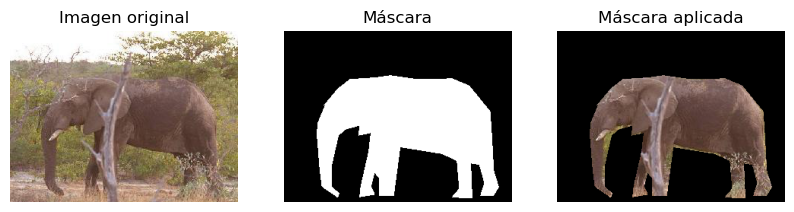

In [35]:
def show(image, mask, image_masked):
    plt.figure(figsize=(10,5))
    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("Imagen original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Máscara")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(image_masked)
    plt.title("Máscara aplicada")
    plt.axis('off')

    plt.show()

# Mostrar la imagen original y la máscara
show(first_image, first_mask, first_image_masked)

- ### El valor de k utilizado será aquel de la imagen con **menor cantidad de píxeles** pertenecientes al animal.

In [36]:
counts = []
num_images = len(images)
for i in range(num_images):
    img = images[i]
    mask = masks[i]

    if len(mask.shape) == 3:
        mask2d = mask[..., 0]
    else:
        mask2d = mask
    
    animal_pixels = np.count_nonzero(mask2d > 0)
    counts.append(animal_pixels)

counts = np.array(counts)
k_global = int(counts.min())
print("Min pixels objeto:", k_global,"Median:", int(np.median(counts)))

Min pixels objeto: 3214 Median: 18062


- ## Función `select_k_pixels()`
- ###  Con esta función seleccionamos **k píxeles pertenecientes al animal**, utilizando la máscara asociada a cada imagen para descartar completamente el fondo. El objetivo es reducir la dimensionalidad de los datos empleando únicamente información relevante del animal, manteniendo un tamaño de entrada fijo para el modelo y mejorando así la eficiencia y el rendimiento del clasificador.

In [37]:
def select_k_pixels(image, mask, k, seed):
    # Forzar a 3 canales si la imagen viene en gris (H,W)
    if len(image.shape) == 2:
        image = np.stack([image, image, image], axis=-1)

    if len(mask.shape) == 3:  # Asegurar máscara 2D
        mask2d = mask[..., 0]
    else:
        mask2d = mask

    mask_bool = mask2d > 0
    animal_pixels = image[mask_bool]
    rng = np.random.default_rng(seed) # Fijamos semilla por imagen, para que al reconstruir X no cambien los píxeles con los que calculamos las features.
    idx = rng.choice(animal_pixels.shape[0], size=k, replace=False)
    
    return animal_pixels[idx].reshape(-1)

- ### Para decidir si nuestros modelos clasifican en 3 clases ("elephant", "rhino" y "resto") o en 4 (los cuatro animales), mostramos por pantalla las muestras que tendríamos de cada clase en cada caso. Como vemos, usando 4 clases evitamos el desbalanceo, ya que ninguna clase domina sobre las demás. Con 3 clases, la etiqueta "resto" tiene el doble de muestras que las demás etiquetas.

In [38]:
# 4 clases
vals_4, cnt_4 = np.unique(label_ids, return_counts=True)

# 3 clases
map3 = {"elephant": 0, "rhino": 1, "emu": 2, "flamingo": 2}
y3 = []
for l in labels:
    mapped = map3[l]
    y3.append(mapped)
y3 = np.array(y3, dtype=int)

vals3, cnt3 = np.unique(y3, return_counts=True)

print("Clasificación en 4 clases")
for cls_id, count in zip(vals_4, cnt_4):
    print(f"  Clase {int(cls_id)} → {int(count)} imágenes")
print("\n-------------------------------------------\n")
print("Clasificación en 3 clases")
for cls_id, count in zip(vals3, cnt3):
    print(f"  Clase {int(cls_id)} → {int(count)} imágenes")

Clasificación en 4 clases
  Clase 0 → 64 imágenes
  Clase 1 → 53 imágenes
  Clase 2 → 67 imágenes
  Clase 3 → 59 imágenes

-------------------------------------------

Clasificación en 3 clases
  Clase 0 → 64 imágenes
  Clase 1 → 59 imágenes
  Clase 2 → 120 imágenes


- ## Función de extracción de características

- ### La función `extract_features()` genera una representación compacta de cada imagen a partir de los píxeles del animal, extrayendo características sobre k píxeles seleccionados.  



In [39]:
def extract_features(image, mask, k, seed):
    # Color
    pixels_flat = select_k_pixels(image, mask, k, seed)
    pixels_k = pixels_flat.reshape(k, 3)  # Volvemos a forma (k,3)

    features = []
    for c in range(3):  # R, G, B
        ch = pixels_k[:, c]
        features.extend([
            np.mean(ch),
            np.std(ch),
            np.min(ch),
            np.max(ch),
            np.percentile(ch, 25),
            np.percentile(ch, 50),
            np.percentile(ch, 75),
        ])

    # Gradiente (Sobel)
    if len(image.shape) == 3:
        gray = rgb2gray(image)
    else:
        gray = image.astype(float) # ya es gris
        if gray.max() > 1.0:
            gray = gray / 255.0
            
    if len(mask.shape) == 3:
        mask2d = mask[..., 0]
    else:
        mask2d = mask
    
    mask_bool = mask2d > 0
    gray_masked = gray * mask_bool
    grad = sobel(gray_masked)
    grad_values = grad[mask2d > 0]
    features.extend([
        np.mean(grad_values),
        np.std(grad_values),
        np.max(grad_values)
    ])

    # Textura
    gray_values = gray[mask2d > 0]
    features.extend([
        np.mean(gray_values),
        np.std(gray_values)
    ])

    return np.array(features, dtype=float)

- ## Dividir en entrenamiento/validación/test

In [40]:
SEED = 42
X_feat = []

num_images = len(images)

for i in range(num_images):
    img  = images[i]
    mask = masks[i]

    features = extract_features(
        img,
        mask,
        k_global,
        seed=SEED + i   # semilla distinta por imagen
    )

    X_feat.append(features)

X_feat = np.array(X_feat, dtype=float)
y = label_ids   # 4 clases

print("X_feat shape:", X_feat.shape)
print("y shape     :", y.shape)

X_feat shape: (243, 26)
y shape     : (243,)


In [41]:
# Split inicial: Train / Test
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_feat,
    y,
    test_size=0.2,        # 20% para test
    random_state=42,
    stratify=y
)

print("Split inicial (Train / Test)")
print(f"  Train: {Xf_train.shape[0]} muestras")
print(f"  Test : {Xf_test.shape[0]} muestras\n")

# Split del Train: Train real / Validation
Xf_train_real, Xf_val, yf_train_real, yf_val = train_test_split(
    Xf_train,
    yf_train,
    test_size=0.2,        # 20% del train para validación
    random_state=42,
    stratify=yf_train
)

print("Segundo split (Train real / Validation)")
print(f"  Train real: {Xf_train_real.shape[0]} muestras")
print(f"  Validation: {Xf_val.shape[0]} muestras\n")

print("Resumen final de particiones")
print(f"  Train real: {Xf_train_real.shape[0]}  (~64%)")
print(f"  Validation: {Xf_val.shape[0]}  (~16%)")
print(f"  Test      : {Xf_test.shape[0]}  (20%)")

Split inicial (Train / Test)
  Train: 194 muestras
  Test : 49 muestras

Segundo split (Train real / Validation)
  Train real: 155 muestras
  Validation: 39 muestras

Resumen final de particiones
  Train real: 155  (~64%)
  Validation: 39  (~16%)
  Test      : 49  (20%)


- ## Normalización

- ### La normalización se realiza calculando la **media y desviación típica** de cada característica a partir del conjunto de entrenamiento real, y aplicando posteriormente esta transformación a los conjuntos de validación y test.

In [42]:
mean = np.mean(Xf_train_real, axis=0)
std = np.std(Xf_train_real, axis=0)
std[std == 0] = 1

Xf_train_real_norm = (Xf_train_real - mean)/std
Xf_val_norm = (Xf_val - mean)/std
Xf_test_norm = (Xf_test - mean)/std

- ## Función para evaluar

- ### La métrica principal empleada es el **F1-score macro**, ya que calcula el rendimiento medio entre todas las clases otorgando la misma importancia a cada una, lo que resulta adecuado en un escenario sin desbalanceo significativo entre clases. Adicionalmente, se reportan la **accuracy** y la **balanced accuracy** para ofrecer una visión global del rendimiento del modelo.

In [43]:
def evaluate_metrics(y_true, y_pred):
    """Métricas recomendables para multiclase."""
    return {
        "acc": accuracy_score(y_true, y_pred),
        "bal_acc": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro")
    }

- ## Función para entrenar

- ### Evaluamos distintas configuraciones de hiperparámetros.

In [48]:
def run_model_selection(models_dict, param_grids, X_train, y_train, X_val, y_val, seed=42, verbose=True):
    results = []

    for model_name, model in models_dict.items():  # Bucle por modelos
        grid = param_grids.get(model_name, {})  # Opciones de hiperparámetros

        if verbose:
            print(f"\n=== Modelo: {model_name} ===")
            print(f"Nº configuraciones: {len(list(ParameterGrid(grid)))}")

        for i, params in enumerate(ParameterGrid(grid), start=1):  # Para todas las combinaciones posibles
            if verbose:
                print(f"  [{i}] Params: {params}")

            m = clone(model)  # Copia del modelo para no reutilizar pesos

            # Si el modelo acepta random_state y no está en params, se lo metemos
            if hasattr(m, "random_state") and ("random_state" not in params):
                try:
                    m.set_params(random_state=seed)
                except Exception:
                    pass

            m.set_params(**params)  # Asignamos hiperparámetros
            m.fit(X_train, y_train)  # Entrenamos

            pred_val = m.predict(X_val)
            met = evaluate_metrics(y_val, pred_val)  # Métricas

            if verbose:
                print(
                    f"      → acc={met['acc']:.4f} | "
                    f"bal_acc={met['bal_acc']:.4f} | "
                    f"f1_macro={met['f1_macro']:.4f}"
                )

            results.append({  # Guardamos en result el nombre del modelo, los hiperparámetros y las métricas
                "model": model_name,
                "params": params,
                **met
            })

    df = pd.DataFrame(results).sort_values(by="f1_macro", ascending=False).reset_index(drop=True)  # Ordenamos descendentemente por f1_macro
    best_model_name = df.loc[0, "model"]  # Extraemos mejor modelo
    best_params = df.loc[0, "params"]  # Extraemos mejores hiperparámetros

    if verbose:
        print("\n=== MEJOR CONFIGURACIÓN (validación) ===")
        print("Modelo :", best_model_name)
        print("Params :", best_params)
        print("F1-macro:", round(df.loc[0, "f1_macro"], 4))

    return df, best_model_name, best_params  # Devolvemos tabla de modelos, modelo ganador e hiperparámetros óptimos

- ### Con `retrain_and_test` podemos entrenar el mejor modelo una vez, usando los datos de entrenamiento y validación (más datos que antes) y evaluar con test. 

In [49]:
def retrain_and_test(
    models_dict,
    best_model_name,
    best_params,
    X_trainval,
    y_trainval,
    X_test,
    y_test,
    seed=42,
    verbose=True
):
    best_model = clone(models_dict[best_model_name])  # Clonamos el mejor modelo

    if verbose:
        print("\n=== ENTRENAMIENTO FINAL ===")
        print("Modelo seleccionado:", best_model_name)
        print("Hiperparámetros:", best_params)

    if hasattr(best_model, "random_state") and ("random_state" not in best_params):  # Reproducibilidad
        try:
            best_model.set_params(random_state=seed)
        except Exception:
            pass

    best_model.set_params(**best_params)  # Mejores parámetros
    best_model.fit(X_trainval, y_trainval)  # Entrenamos con más datos que antes

    if verbose:
        print("Entrenamiento completado.")

    pred_test = best_model.predict(X_test)
    met_test = evaluate_metrics(y_test, pred_test)  # Métricas

    if verbose:
        print("\n=== RESULTADOS EN TEST ===")
        for k, v in met_test.items():
            print(f"{k}: {v:.4f}")

    cm = confusion_matrix(y_test, pred_test)
    report = classification_report(y_test, pred_test, digits=4)

    if verbose:
        print("\nMatriz de confusión (TEST):")
        print(cm)
        print("\nClassification report (TEST):")
        print(report)

    return best_model, met_test, cm, report


- ## Hiperparámetros

In [46]:
SEED = 42

models_dict = {
    "knn": KNeighborsClassifier(),
    "svm_rbf": SVC(kernel="rbf"),                 # SVM con RBF
    "rf": RandomForestClassifier(),               # Bosque aleatorio
    "logreg": LogisticRegression(max_iter=5000)   # Regresión logística multiclase
}

param_grids = {
    "knn": {
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
        "p": [1, 2]  # 1=Manhattan, 2=Euclídea
    },
    "svm_rbf": {
        "C": [0.1, 1, 10, 50],
        "gamma": ["scale", "auto"]
    },
    "rf": {
        "n_estimators": [100, 200, 400],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },
    "logreg": {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs"],
        "multi_class": ["auto"]
    }
}

In [50]:
df_results, best_model_name, best_params = run_model_selection(
    models_dict,
    param_grids,
    Xf_train_real_norm, yf_train_real,
    Xf_val_norm, yf_val,
    seed=SEED,
    verbose = True
)

print("TOP 10 configuraciones (ordenado por F1-macro en VALIDACIÓN):")
display(df_results.head(10))

print("\nMEJOR CONFIGURACIÓN (VALIDACIÓN):")
print("  Modelo :", best_model_name)
print("  Params :", best_params)
print("  F1-macro:", round(df_results.loc[0, "f1_macro"], 4),
      "| Acc:", round(df_results.loc[0, "acc"], 4),
      "| Bal-Acc:", round(df_results.loc[0, "bal_acc"], 4))


=== Modelo: knn ===
Nº configuraciones: 20
  [1] Params: {'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}
      → acc=0.4103 | bal_acc=0.3966 | f1_macro=0.3734
  [2] Params: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
      → acc=0.4872 | bal_acc=0.4716 | f1_macro=0.4699
  [3] Params: {'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
      → acc=0.5385 | bal_acc=0.5301 | f1_macro=0.5250
  [4] Params: {'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
      → acc=0.5385 | bal_acc=0.5426 | f1_macro=0.5399
  [5] Params: {'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}
      → acc=0.4872 | bal_acc=0.4841 | f1_macro=0.4503
  [6] Params: {'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
      → acc=0.4615 | bal_acc=0.4591 | f1_macro=0.4448
  [7] Params: {'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
      → acc=0.4615 | bal_acc=0.4551 | f1_macro=0.4417
  [8] Params: {'n_neighbors': 5, 'p': 2, 'weights': 'distance'}
      → acc=0.5641 | bal_acc=0.5676 | f1_macro=0.5678
  [9] Params: {'

c:\Users\Pc\anaconda3\envs\PVC\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Pc\anaconda3\envs\PVC\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Pc\anaconda3\envs\PVC\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,model,params,acc,bal_acc,f1_macro
0,svm_rbf,"{'C': 10, 'gamma': 'auto'}",0.743590,0.742045,0.755952
1,svm_rbf,"{'C': 10, 'gamma': 'scale'}",0.743590,0.742045,0.755952
2,svm_rbf,"{'C': 50, 'gamma': 'auto'}",0.717949,0.719318,0.727193
3,svm_rbf,"{'C': 50, 'gamma': 'scale'}",0.717949,0.719318,0.727193
4,logreg,"{'C': 1, 'multi_class': 'auto', 'solver': 'lbf...",0.692308,0.689773,0.698996
5,rf,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.666667,0.669318,0.666842
6,rf,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.666667,0.669318,0.660878
7,logreg,"{'C': 0.1, 'multi_class': 'auto', 'solver': 'l...",0.641026,0.635795,0.652264
8,rf,"{'max_depth': 30, 'min_samples_leaf': 1, 'min_...",0.641026,0.644318,0.635568
9,rf,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.641026,0.644318,0.635568



MEJOR CONFIGURACIÓN (VALIDACIÓN):
  Modelo : svm_rbf
  Params : {'C': 10, 'gamma': 'auto'}
  F1-macro: 0.756 | Acc: 0.7436 | Bal-Acc: 0.742


In [52]:
# Unimos train_real + val para entrenar el modelo final
X_trainval = np.vstack([Xf_train_real_norm, Xf_val_norm])
y_trainval = np.concatenate([yf_train_real, yf_val])

best_model, met_test, cm, report = retrain_and_test(
    models_dict,
    best_model_name,
    best_params,
    X_trainval, y_trainval,
    Xf_test_norm, yf_test,
    seed=SEED,
    verbose=True
)

print("RESULTADOS EN TEST (modelo final):")
print(f"  Acc      : {met_test['acc']:.4f}")
print(f"  Bal-Acc  : {met_test['bal_acc']:.4f}")
print(f"  F1-macro : {met_test['f1_macro']:.4f}")

print("\nMatriz de confusión (TEST):")
print(cm)

print("\nClassification report (TEST):")
print(report)


=== ENTRENAMIENTO FINAL ===
Modelo seleccionado: svm_rbf
Hiperparámetros: {'C': 10, 'gamma': 'auto'}
Entrenamiento completado.

=== RESULTADOS EN TEST ===
acc: 0.6735
bal_acc: 0.6709
f1_macro: 0.6442

Matriz de confusión (TEST):
[[ 9  2  0  2]
 [ 0  9  2  0]
 [ 0  1 12  0]
 [ 6  3  0  3]]

Classification report (TEST):
              precision    recall  f1-score   support

           0     0.6000    0.6923    0.6429        13
           1     0.6000    0.8182    0.6923        11
           2     0.8571    0.9231    0.8889        13
           3     0.6000    0.2500    0.3529        12

    accuracy                         0.6735        49
   macro avg     0.6643    0.6709    0.6442        49
weighted avg     0.6682    0.6735    0.6482        49

RESULTADOS EN TEST (modelo final):
  Acc      : 0.6735
  Bal-Acc  : 0.6709
  F1-macro : 0.6442

Matriz de confusión (TEST):
[[ 9  2  0  2]
 [ 0  9  2  0]
 [ 0  1 12  0]
 [ 6  3  0  3]]

Classification report (TEST):
              precision    